In [7]:
%autosave 300
%load_ext autoreload
%autoreload 2 
%reload_ext autoreload
%config Completer.use_jedi = False

Autosaving every 300 seconds
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os

os.chdir(
    "/mnt/batch/tasks/shared/LS_root/mounts/clusters/copilot-model-run/code/Users/Soutrik.Chowdhury/ERAV2_Advanced_VisionTransformers"
)
print(os.getcwd())

/mnt/batch/tasks/shared/LS_root/mounts/clusters/copilot-model-run/code/Users/Soutrik.Chowdhury/ERAV2_Advanced_VisionTransformers


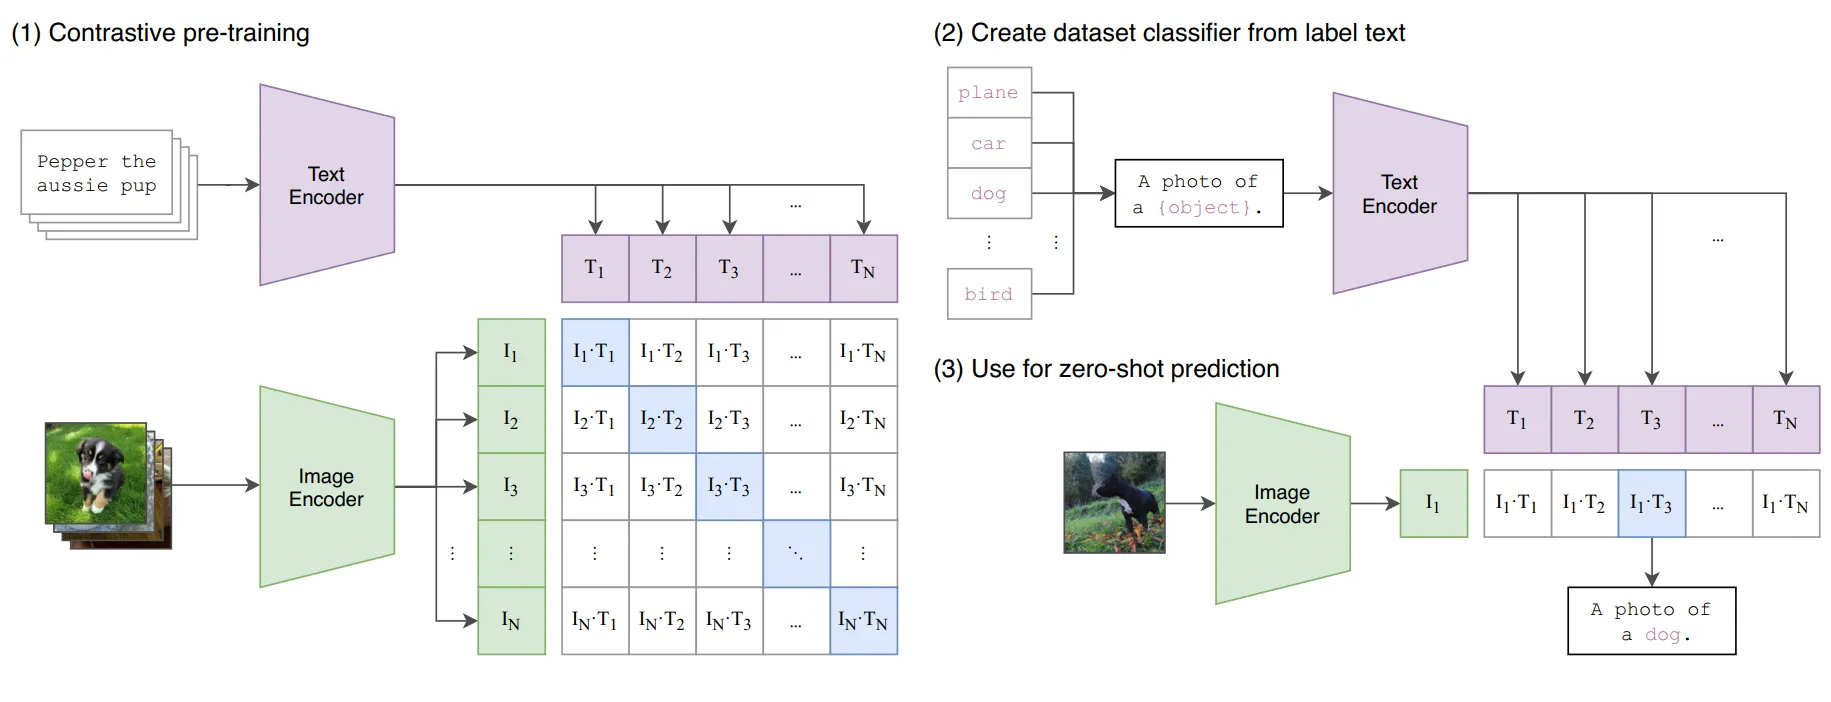

In [9]:
# !kaggle datasets download -d adityajn105/flickr8k
# !unzip flickr8k.zip
# dataset = "8k"

In [10]:
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import cv2
import torch
import albumentations as A
from torch.utils.data import Dataset,DataLoader
import timm

In [11]:
df = pd.read_csv("captions.txt")
df['id'] = [id_ for id_ in range(df.shape[0] // 5) for _ in range(5)]
df.to_csv("captions.csv", index=False)
df = pd.read_csv("captions.csv")
image_path = "./Images"
captions_path = "./content"

In [12]:
df.loc[df['image']=='17273391_55cfc7d3d4.jpg']

,image,caption,id
3420,17273391_55cfc7d3d4.jpg,A fisherman fishes at the bank of a foggy river .,684
3421,17273391_55cfc7d3d4.jpg,A man fishes by a tree in the morning mist .,684
3422,17273391_55cfc7d3d4.jpg,A man fishes under a large tree .,684
3423,17273391_55cfc7d3d4.jpg,A man fishing near a large tree .,684
3424,17273391_55cfc7d3d4.jpg,A man is fishing in a foggy lake .,684


In [13]:
class CFG:
    debug = False
    image_path = image_path
    captions_path = captions_path
    batch_size = 32
    num_workers = 2
    head_lr = 1e-3
    image_encoder_lr = 1e-4
    text_encoder_lr = 1e-5
    weight_decay = 1e-3
    patience = 1
    factor = 0.8
    epochs = 4
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_name = 'resnet50'
    image_embedding = 2048
    text_encoder_model = "distilbert-base-uncased"
    text_embedding = 768
    text_tokenizer = "distilbert-base-uncased"
    max_length = 200

    pretrained = True # for both image encoder and text encoder
    trainable = True # for both image encoder and text encoder
    temperature = 1.0

    # image size
    size = 224

    # for projection head; used for both image and text encoders
    num_projection_layers = 1
    projection_dim = 256 
    dropout = 0.1

In [14]:
# we create a pytorch dataset which return both image and caption in encoded format

In [15]:
class ClipDataset(Dataset):
    def __init__(self, image_filenames, captions, tokenizer, transforms):
        self.image_filenames = image_filenames
        self.captions = list(captions)
        self.transforms = transforms
        self.encoded_captions = tokenizer(
            list(captions), padding=True, truncation=True, max_length=CFG.max_length
        )
        
    def __getitem__(self, idx):
        item = {
            key: torch.tensor(values[idx])
            for key, values in self.encoded_captions.items()
        }

        image = cv2.imread(f"{CFG.image_path}/{self.image_filenames[idx]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transforms(image=image)['image']
        item['image'] = torch.tensor(image).permute(2, 0, 1).float()
        item['caption'] = self.captions[idx]

        return item


    def __len__(self):
        return len(self.captions)

Image encoder - The code encodes each image to a fixed size vector with the size of the model's output channels (in case of ResNet50 the vector size will be 2048).

In [16]:
class ImageEncoder(nn.Module):
    def __init__(self,model_name=CFG.model_name, pretrained=CFG.pretrained, trainable=CFG.trainable):
        super().__init__()
        self.model = timm.create_model(
            model_name, pretrained, num_classes=0, global_pool="avg"
        )
        
        for p in self.model.parameters():
            p.requires_grad = trainable
            
    def forward(self,x):
        op = self.model(x)
        return(op)

Text Encoder-  DistilBERT (and also BERT) the output hidden representation for each token is a vector with size 768.

In [17]:
class TextEncoder(nn.Module):
    def __init__(self,model_name=CFG.text_encoder_model, pretrained=CFG.pretrained, trainable=CFG.trainable):
        super().__init__()
        if pretrained:
            self.model = DistilBertModel.from_pretrained(model_name)
        else:
            self.model = DistilBertModel(config=DistilBertConfig())
            
        for p in self.model.parameters():
            p.requires_grad = trainable

        # we are using the CLS token hidden representation as the sentence's embedding
        self.target_token_idx = 0
        
    def forward(self, input_ids, attention_mask):
        output = self.model(input_ids = input_ids, attention_mask = attention_mask)
        last_hidden_state = output.last_hidden_state
        return last_hidden_state[:, self.target_token_idx, :]

the following code will bring the 2048 and 768 dimensional vectors into a 256 (projection_dim) dimensional world, where we can compare them.

"embedding_dim" is the size of the input vector (2048 for images and 768 for texts) and "projection_dim" is the the size of the output vector which will be 256 for our case
Why - because we have to compare the text and images, so we need to have the same dims